In [92]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [93]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [130]:
df_train

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,42,9,1,1,0,7,0,0,0,25,1,117,3,-1,0,3,0
1,38,1,1,1,0,514,0,0,2,18,6,185,1,-1,0,3,0
2,36,1,1,1,0,602,1,0,2,14,8,111,2,-1,0,3,0
3,27,8,2,1,0,34,1,0,2,28,8,10,2,-1,0,3,0
4,26,9,1,1,0,889,1,0,0,3,3,902,1,-1,0,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,29,7,2,1,0,1282,0,1,2,4,5,1006,2,-1,0,3,1
749996,69,5,0,2,0,631,0,0,0,19,1,87,1,-1,0,3,0
749997,50,1,1,1,0,217,1,0,0,17,0,113,1,-1,0,3,0
749998,32,9,1,1,0,-274,0,0,0,26,1,108,6,-1,0,3,0


In [131]:
df_test

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,32,1,1,1,0,1397,1,0,2,21,8,224,1,-1,0,3
1,44,4,1,2,0,23,1,0,0,3,0,586,2,-1,0,3
2,36,6,1,0,0,46,1,1,0,13,8,111,2,-1,0,3
3,58,1,1,1,0,-1380,1,1,2,29,8,125,1,-1,0,3
4,28,9,2,1,0,1950,1,0,0,22,5,181,1,-1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,43,4,1,2,0,0,1,0,0,18,9,65,2,-1,0,3
249996,40,7,1,3,0,522,1,0,0,19,9,531,1,189,1,0
249997,63,5,1,0,0,33,0,0,0,3,5,178,1,92,8,2
249998,50,1,1,0,0,2629,1,0,2,30,8,163,2,-1,0,3


In [96]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB


In [97]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         250000 non-null  int64 
 1   age        250000 non-null  int64 
 2   job        250000 non-null  object
 3   marital    250000 non-null  object
 4   education  250000 non-null  object
 5   default    250000 non-null  object
 6   balance    250000 non-null  int64 
 7   housing    250000 non-null  object
 8   loan       250000 non-null  object
 9   contact    250000 non-null  object
 10  day        250000 non-null  int64 
 11  month      250000 non-null  object
 12  duration   250000 non-null  int64 
 13  campaign   250000 non-null  int64 
 14  pdays      250000 non-null  int64 
 15  previous   250000 non-null  int64 
 16  poutcome   250000 non-null  object
dtypes: int64(8), object(9)
memory usage: 32.4+ MB


In [98]:
df_train.isna().sum()

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [99]:
df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)

In [100]:
from sklearn.preprocessing import LabelEncoder

In [101]:
label = LabelEncoder()

In [102]:
df_train['job'].value_counts()

job
management       175541
blue-collar      170498
technician       138107
admin.            81492
services          64209
retired           35185
self-employed     19020
entrepreneur      17718
unemployed        17634
housemaid         15912
student           11767
unknown            2917
Name: count, dtype: int64

In [103]:
df_train['job'] = label.fit_transform(df_train['job'])
df_test['job'] = label.transform(df_test['job'])

In [104]:
df_train['marital'] = label.fit_transform(df_train['marital'])
df_test['marital'] = label.transform(df_test['marital'])

In [105]:
df_train['education'] = label.fit_transform(df_train['education'])
df_test['education'] = label.transform(df_test['education'])

In [106]:
df_train['default'] = label.fit_transform(df_train['default'])
df_test['default'] = label.transform(df_test['default'])

In [107]:
df_train['housing'] = label.fit_transform(df_train['housing'])
df_test['housing'] = label.transform(df_test['housing'])

In [108]:
df_train['loan'] = label.fit_transform(df_train['loan'])
df_test['loan'] = label.transform(df_test['loan'])

In [109]:
df_train['contact'] = label.fit_transform(df_train['contact'])
df_test['contact'] = label.transform(df_test['contact'])

In [110]:
df_train['month'] = label.fit_transform(df_train['month'])
df_test['month'] = label.transform(df_test['month'])

In [111]:
df_train['poutcome'] = label.fit_transform(df_train['poutcome'])
df_test['poutcome'] = label.transform(df_test['poutcome'])

In [112]:
X_train = df_train.drop('y', axis=1)
y_train = df_train['y']
X_test = df_test.copy()

In [113]:
from sklearn.preprocessing import StandardScaler

In [114]:
scaler = StandardScaler()

In [115]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [116]:
from keras.utils import to_categorical

In [117]:
y_train = to_categorical(y_train,num_classes=2)

In [118]:
y_train.shape

(750000, 2)

In [119]:
from keras import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

In [120]:
X_train.shape

(750000, 16)

In [121]:
model = Sequential()
model.add(Dense(units=16, activation='relu', input_shape=(16, )))
model.add(Dense(units=8, activation='relu'))
model.add(Dense(units=2, activation='softmax'))

C:\Users\USER\Desktop\ML jupyter\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [122]:
model.compile(optimizer = Adam(learning_rate = 0.001),loss = 'binary_crossentropy', metrics=['accuracy'])

In [123]:
model.fit(X_train,y_train, validation_split = 0.30, epochs = 15)

Epoch 1/15
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 68s 4ms/step - accuracy: 0.9116 - loss: 0.1967 - val_accuracy: 0.9179 - val_loss: 0.1844
Epoch 2/15
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 76s 4ms/step - accuracy: 0.9193 - loss: 0.1819 - val_accuracy: 0.9200 - val_loss: 0.1808
Epoch 3/15
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 88s 4ms/step - accuracy: 0.9204 - loss: 0.1802 - val_accuracy: 0.9211 - val_loss: 0.1801
Epoch 4/15
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 83s 4ms/step - accuracy: 0.9211 - loss: 0.1794 - val_accuracy: 0.9205 - val_loss: 0.1798
Epoch 5/15
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 82s 4ms/step - accuracy: 0.9216 - loss: 0.1785 - val_accuracy: 0.9208 - val_loss: 0.1790
Epoch 6/15
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 80s 4ms/step - accuracy: 0.9219 - loss: 0.1777 - val_accuracy: 0.9219 - val_loss: 0.1777
Epoch 7/15
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 83s 4ms/step - accuracy: 0.9222 - loss: 0.1768 - val_accuracy: 0.9223 - val_loss: 0.1769
Epoch 8/15
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 82s 4ms/step - accuracy: 

In [125]:
y_pred = model.predict(X_test)

7813/7813 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


In [126]:
y_pred

array([[9.9996924e-01, 3.0742332e-05],
       [9.3212122e-01, 6.7878760e-02],
       [9.9999666e-01, 3.3489282e-06],
       ...,
       [1.1367689e-01, 8.8632315e-01],
       [9.9999809e-01, 1.9092313e-06],
       [9.9045545e-01, 9.5445756e-03]], shape=(250000, 2), dtype=float32)

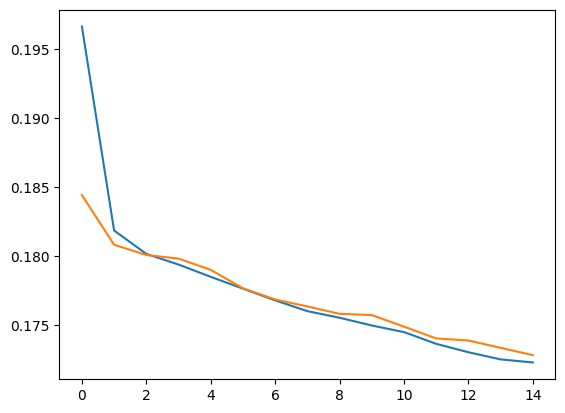

In [127]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

In [128]:
df_sub = pd.read_csv('sample_submission.csv')

In [132]:
df_sub['y'] = y_pred

In [133]:
df_sub.to_csv('sub.csv',index = False, index_label= False)